In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
from pathlib import Path
import os

ZIP_PATH = "/content/drive/MyDrive/Cardamom_leaf_disease_split.zip"
EXTRACT_DIR = Path("/content/cardamom_dataset")

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted successfully!")
print("Extracted files:")
for item in EXTRACT_DIR.iterdir():
    print(item)

Dataset extracted successfully!
Extracted files:
/content/cardamom_dataset/test
/content/cardamom_dataset/train
/content/cardamom_dataset/val


In [ ]:
from pathlib import Path

def find_dataset_root(base_dir):
    base_dir = Path(base_dir)

    for path in [base_dir] + list(base_dir.rglob("*")):
        if path.is_dir():
            train_dir = path / "train"
            val_dir = path / "val"
            test_dir = path / "test"

            if train_dir.exists() and val_dir.exists() and test_dir.exists():
                return path

    raise FileNotFoundError("Could not find dataset folder with train, val, and test folders.")

DATASET_ROOT = find_dataset_root(EXTRACT_DIR)

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "val"
TEST_DIR = DATASET_ROOT / "test"

print("Dataset root:", DATASET_ROOT)
print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

print("\nClasses:")
for folder in TRAIN_DIR.iterdir():
    if folder.is_dir():
        print(folder.name, "=", len(list(folder.glob("*"))))

Dataset root: /content/cardamom_dataset
Train: /content/cardamom_dataset/train
Validation: /content/cardamom_dataset/val
Test: /content/cardamom_dataset/test

Classes:
healthy = 546
phyllosticta_leaf_spot = 464
leaf_blight = 196


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from sklearn.metrics import classification_report, confusion_matrix
import itertools

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Found 1206 files belonging to 3 classes.
Found 259 files belonging to 3 classes.
Found 259 files belonging to 3 classes.
Class names: ['healthy', 'leaf_blight', 'phyllosticta_leaf_spot']
Number of classes: 3


In [ ]:
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [ ]:
def count_images_per_class(directory, class_names):
    counts = []
    for class_name in class_names:
        class_dir = Path(directory) / class_name
        count = len([p for p in class_dir.rglob("*") if p.is_file()])
        counts.append(count)
    return counts

train_counts = count_images_per_class(TRAIN_DIR, class_names)

total_train = sum(train_counts)
class_weights = {}

for i, count in enumerate(train_counts):
    class_weights[i] = total_train / (num_classes * count)

print("Train counts:", dict(zip(class_names, train_counts)))
print("Class weights:", class_weights)

Train counts: {'healthy': 546, 'leaf_blight': 196, 'phyllosticta_leaf_spot': 464}
Class weights: {0: 0.7362637362637363, 1: 2.0510204081632653, 2: 0.8663793103448276}


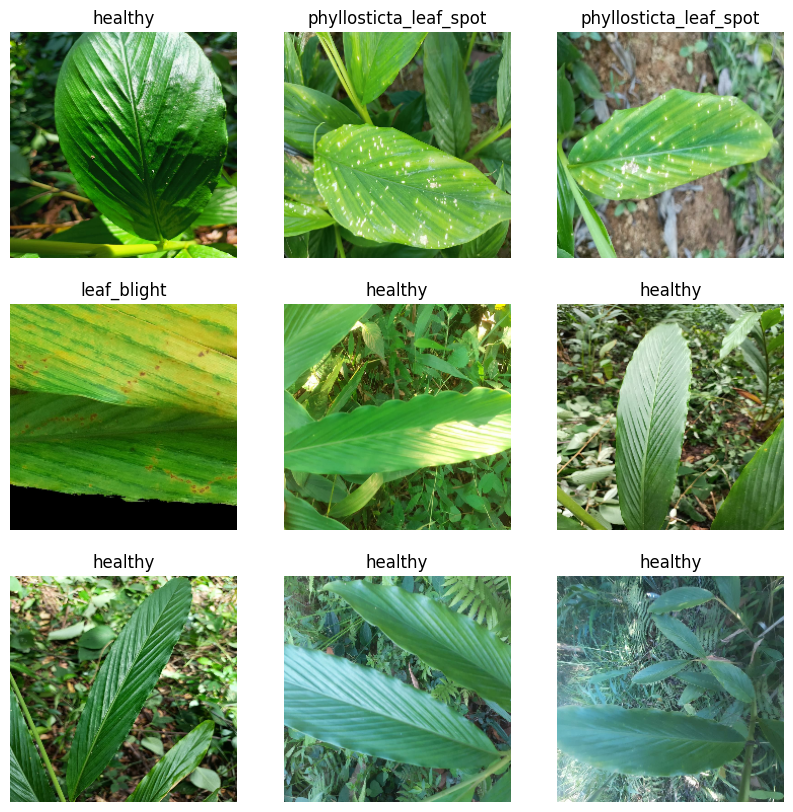

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.show()

In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ],
    name="data_augmentation"
)

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3),
    pooling=None
)

base_model.trainable = False

inputs = keras.Input(shape=(224, 224, 3), name="input_image")

x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="avg_pool")(x)
x = layers.Dropout(0.35, name="top_dropout")(x)

outputs = layers.Dense(
    num_classes,
    activation="softmax",
    name="predictions"
)(x)

model = keras.Model(inputs, outputs, name="cardamom_leaf_disease_efficientnetb0")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "cardamom_leaf_disease_efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dropout (Dropout)           │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
SAVE_DIR = Path("/content/drive/MyDrive/Cardamom_Project_leaf_diseases/model_outputs")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = SAVE_DIR / "best_cardamom_leaf_model.keras"
FINAL_MODEL_PATH = SAVE_DIR / "final_cardamom_leaf_model.keras"
LABELS_PATH = SAVE_DIR / "class_names.json"

with open(LABELS_PATH, "w") as f:
    json.dump(class_names, f, indent=4)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print("Model will be saved to:", BEST_MODEL_PATH)

Model will be saved to: /content/drive/MyDrive/Cardamom_Project_leaf_diseases/model_outputs/best_cardamom_leaf_model.keras


In [ ]:
EPOCHS_STAGE_1 = 20

history_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE_1,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.6311 - loss: 0.8273
Epoch 1: val_accuracy improved from None to 0.96139, saving model to /content/drive/MyDrive/Cardamom_Project_leaf_diseases/model_outputs/best_cardamom_leaf_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Cardamom_Project_leaf_diseases/model_outputs/best_cardamom_leaf_model.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 29s 299ms/step - accuracy: 0.7579 - loss: 0.5991 - val_accuracy: 0.9614 - val_loss: 0.3401 - learning_rate: 0.0010
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.9342 - loss: 0.2487
Epoch 2: val_accuracy improved from 0.96139 to 0.98070, saving model to /content/drive/MyDrive/Cardamom_Project_leaf_diseases/model_outputs/best_cardamom_leaf_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Cardamom_Project_leaf_diseases/model_outputs/best_cardamom_leaf_model.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 178ms/step - accuracy: 0.9494 - loss: 0.2223 - va

In [ ]:
base_model.trainable = True

# Keep BatchNorm layers frozen for stable fine-tuning
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Freeze earlier layers, train only later layers
fine_tune_at = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Total base model layers:", len(base_model.layers))
print("Fine-tuning from layer:", fine_tune_at)

Total base model layers: 238
Fine-tuning from layer: 208


In [ ]:
EPOCHS_STAGE_2 = 20

history_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE_2,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9906 - loss: 0.0298
Epoch 1: val_accuracy did not improve from 1.00000
38/38 ━━━━━━━━━━━━━━━━━━━━ 24s 296ms/step - accuracy: 0.9900 - loss: 0.0303 - val_accuracy: 1.0000 - val_loss: 0.0200 - learning_rate: 1.0000e-05
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.9959 - loss: 0.0183
Epoch 2: val_accuracy did not improve from 1.00000
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 196ms/step - accuracy: 0.9942 - loss: 0.0210 - val_accuracy: 1.0000 - val_loss: 0.0176 - learning_rate: 1.0000e-05
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9958 - loss: 0.0159
Epoch 3: val_accuracy did not improve from 1.00000
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 173ms/step - accuracy: 0.9959 - loss: 0.0142 - val_accuracy: 1.0000 - val_loss: 0.0152 - learning_rate: 1.0000e-05
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9951 - loss: 0.0199
Epoch 4: val_accuracy did not improve from 1.00000
38/38 ━━━━━━━━━━

In [ ]:
model.save(FINAL_MODEL_PATH)

print("Final model saved to:", FINAL_MODEL_PATH)
print("Best model saved to:", BEST_MODEL_PATH)
print("Class names saved to:", LABELS_PATH)

Final model saved to: /content/drive/MyDrive/Cardamom_Project_leaf_diseases/model_outputs/final_cardamom_leaf_model.keras
Best model saved to: /content/drive/MyDrive/Cardamom_Project_leaf_diseases/model_outputs/best_cardamom_leaf_model.keras
Class names saved to: /content/drive/MyDrive/Cardamom_Project_leaf_diseases/model_outputs/class_names.json


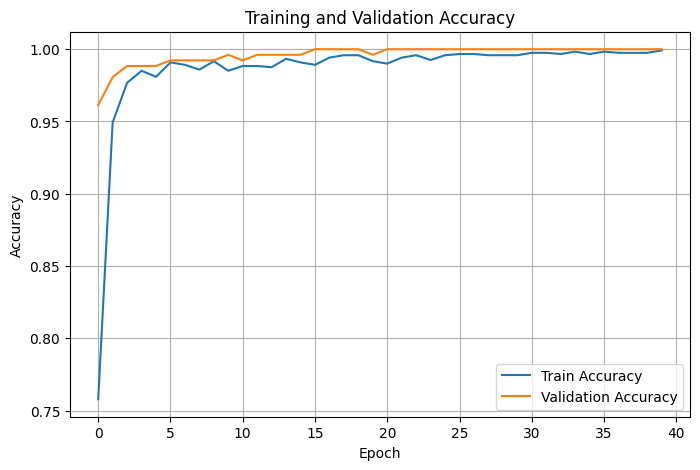

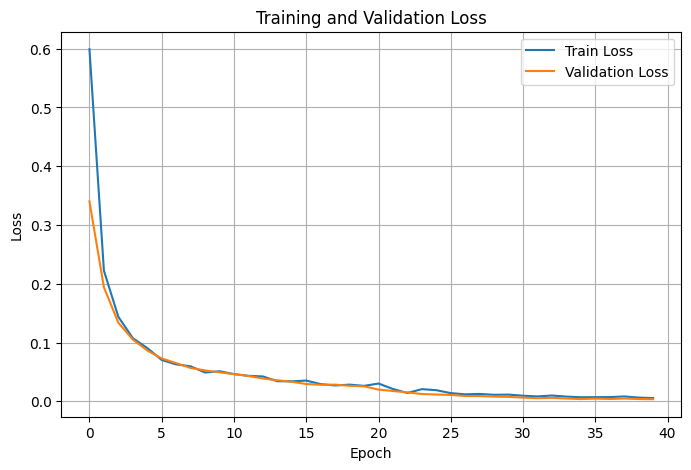

In [ ]:
def combine_history(h1, h2):
    history = {}

    for key in h1.history.keys():
        history[key] = h1.history[key] + h2.history.get(key, [])

    return history

history = combine_history(history_1, history_2)

plt.figure(figsize=(8, 5))
plt.plot(history["accuracy"], label="Train Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_model = keras.models.load_model(BEST_MODEL_PATH)

test_loss, test_accuracy = best_model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 203ms/step - accuracy: 0.9923 - loss: 0.0345
Test Loss: 0.03448115289211273
Test Accuracy: 0.992277979850769


In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

                        precision    recall  f1-score   support

               healthy     0.9915    0.9915    0.9915       118
           leaf_blight     0.9767    1.0000    0.9882        42
phyllosticta_leaf_spot     1.0000    0.9899    0.9949        99

              accuracy                         0.9923       259
             macro avg     0.9894    0.9938    0.9916       259
          weighted avg     0.9924    0.9923    0.9923       259



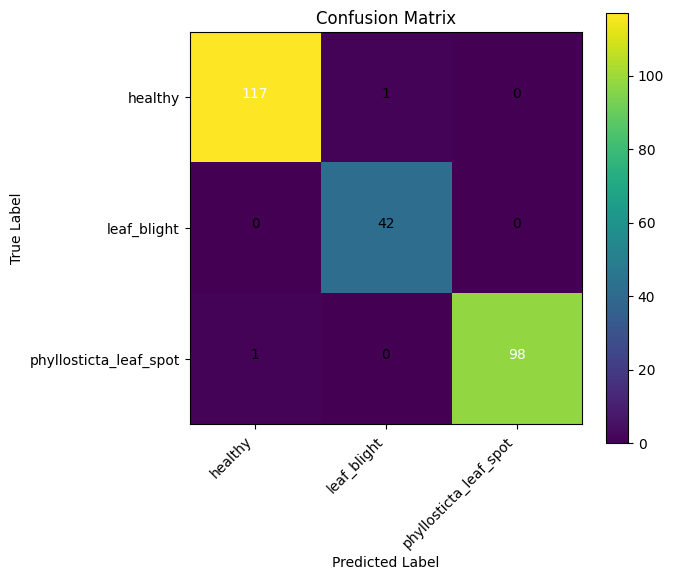

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

threshold = cm.max() / 2

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        cm[i, j],
        horizontalalignment="center",
        color="white" if cm[i, j] > threshold else "black"
    )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

Saving 528439_1_En_55_Fig9_HTML.jpg to 528439_1_En_55_Fig9_HTML.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step


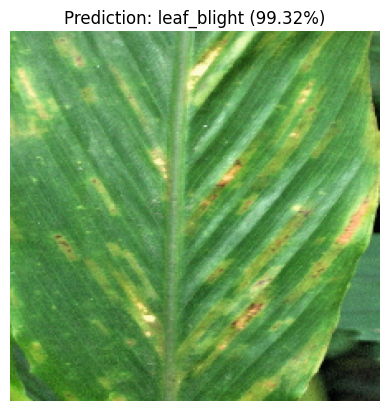

Prediction: leaf_blight
Confidence: 99.32%

All class probabilities:
healthy: 0.09%
leaf_blight: 99.32%
phyllosticta_leaf_spot: 0.59%


In [ ]:
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array

uploaded = files.upload()

for file_name in uploaded.keys():
    img_path = file_name

    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_array_batch = np.expand_dims(img_array, axis=0)

    preds = best_model.predict(img_array_batch)
    pred_index = np.argmax(preds[0])
    confidence = float(preds[0][pred_index]) * 100

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {class_names[pred_index]} ({confidence:.2f}%)")
    plt.show()

    print("Prediction:", class_names[pred_index])
    print("Confidence:", f"{confidence:.2f}%")
    print("\nAll class probabilities:")
    for cls, prob in zip(class_names, preds[0]):
        print(f"{cls}: {prob * 100:.2f}%")

In [ ]:
TFLITE_MODEL_PATH = SAVE_DIR / "cardamom_leaf_model.tflite"

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()

with open(TFLITE_MODEL_PATH, "wb") as f:
    f.write(tflite_model)

print("TFLite model saved to:", TFLITE_MODEL_PATH)

Saved artifact at '/tmp/tmpze7u_90m'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  135307348968080: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135307348969616: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135307277914320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135307277913360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135307277912592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135307277915088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135307277915664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135307277915856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135307277910480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135307277915280: TensorSpec(shape=(), dtype=tf.resource, name=None)

In [ ]:
results = {
    "class_names": class_names,
    "train_counts": dict(zip(class_names, train_counts)),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "class_weights": {str(k): float(v) for k, v in class_weights.items()}
}

RESULTS_PATH = SAVE_DIR / "training_results.json"

with open(RESULTS_PATH, "w") as f:
    json.dump(results, f, indent=4)

print("Training results saved to:", RESULTS_PATH)

Training results saved to: /content/drive/MyDrive/Cardamom_Project_leaf_diseases/model_outputs/training_results.json


Outer model: efficientnetb0
Last conv layer: top_conv


Saving 528439_1_En_55_Fig9_HTML.jpg to 528439_1_En_55_Fig9_HTML (2).jpg


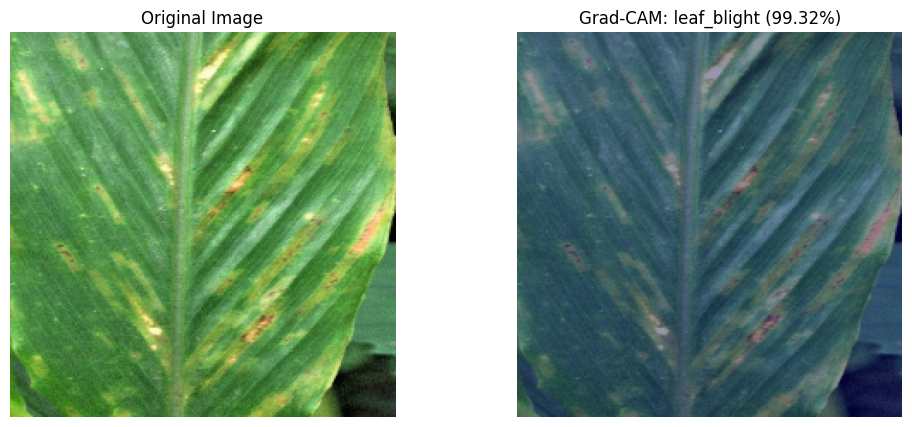

Prediction: leaf_blight
Confidence: 99.32%

All class probabilities:
healthy: 0.09%
leaf_blight: 99.32%
phyllosticta_leaf_spot: 0.59%


In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.utils import load_img, img_to_array
from google.colab import files

# Find EfficientNet and last conv layer
base_model = best_model.get_layer("efficientnetb0")
last_conv_layer_name = "top_conv"

last_conv_layer = base_model.get_layer(last_conv_layer_name)

print("Outer model:", base_model.name)
print("Last conv layer:", last_conv_layer.name)

# Model from EfficientNet input to last conv output
last_conv_model = keras.Model(
    inputs=base_model.input,
    outputs=last_conv_layer.output
)

# Build classifier part after EfficientNet
classifier_input = keras.Input(shape=last_conv_layer.output.shape[1:])
x = classifier_input

start = False
for layer in best_model.layers:
    if layer.name == base_model.name:
        start = True
        continue

    if start:
        if isinstance(layer, tf.keras.layers.Dropout):
            x = layer(x, training=False)
        else:
            x = layer(x)

classifier_model = keras.Model(classifier_input, x)


def apply_layers_before_base_model(img_batch):
    x = img_batch

    for layer in best_model.layers:
        if layer.name == base_model.name:
            break

        # Skip InputLayer
        if isinstance(layer, tf.keras.layers.InputLayer):
            continue

        try:
            x = layer(x, training=False)
        except TypeError:
            x = layer(x)

    return x


def make_gradcam_heatmap(img_batch, pred_index=None):
    x = apply_layers_before_base_model(img_batch)

    with tf.GradientTape() as tape:
        conv_outputs = last_conv_model(x, training=False)
        tape.watch(conv_outputs)

        predictions = classifier_model(conv_outputs, training=False)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)
    heatmap = heatmap / (max_value + 1e-8)

    return heatmap.numpy(), predictions.numpy()


def display_gradcam(image_path, alpha=0.4):
    img = load_img(image_path, target_size=IMG_SIZE, color_mode="rgb")
    img_array = img_to_array(img).astype("float32")
    img_batch = np.expand_dims(img_array, axis=0)

    # Normal prediction
    preds = best_model.predict(img_batch, verbose=0)
    pred_index = int(np.argmax(preds[0]))
    confidence = float(preds[0][pred_index]) * 100

    # Grad-CAM
    heatmap, _ = make_gradcam_heatmap(img_batch, pred_index)

    original_img = np.array(img).astype("uint8")

    heatmap = cv2.resize(heatmap, (IMG_SIZE[1], IMG_SIZE[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    superimposed_img = cv2.addWeighted(
        original_img,
        1 - alpha,
        heatmap_colored,
        alpha,
        0
    )

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title(f"Grad-CAM: {class_names[pred_index]} ({confidence:.2f}%)")
    plt.axis("off")

    plt.show()

    print("Prediction:", class_names[pred_index])
    print("Confidence:", f"{confidence:.2f}%")

    print("\nAll class probabilities:")
    for cls, prob in zip(class_names, preds[0]):
        print(f"{cls}: {prob * 100:.2f}%")


uploaded = files.upload()

for file_name in uploaded.keys():
    display_gradcam(file_name)